In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'dynamic_tests': 1, 'static_tests': 1}

In [3]:
TEST_NUM = OPTIONS['dynamic_tests']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test1'

In [4]:
TARGET_VAR  = 'pitch'
TARGET_TIME = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits') 
TARGET_TIME

[0, 1000000000.0]

# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,wx,tmp,wz,yaw,roll,az,time,wy,pitch,ax,ay
0,23276,60.5,7991,353504,4355,994847,0.000000,-19945,1964,-75600,40037
1,1124,60.5,-12805,353484,4358,992576,0.043499,-34067,1958,-79429,32623
2,-23899,60.5,20591,353483,4359,997090,0.140979,2385,1958,-79910,36633
3,-5959,60.2,-21019,353484,4363,993158,0.247164,-802,1957,-69673,37573
4,-27809,60.5,2057,353481,4360,991753,0.348991,21453,1963,-71383,34182
...,...,...,...,...,...,...,...,...,...,...,...
669,-3999,60.5,-11702,353194,4356,994496,66.856288,30606,1976,-78215,31169
670,-8075,60.5,-9941,353193,4357,991208,66.957086,-22989,1975,-72142,37907
671,-15441,60.5,4488,353194,4356,997072,67.063414,45741,1975,-76694,33446
672,3487,60.5,-35198,353196,4355,993113,67.164494,-18754,1975,-74784,36873


- Convertendo pra radianos

In [6]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,wx,tmp,wz,yaw,roll,az,time,wy,pitch,ax,ay
0,0.23276,60.5,0.07991,353.504,4.355,9.756116,0.000000,-0.19945,1.964,-0.741383,0.392629
1,0.01124,60.5,-0.12805,353.484,4.358,9.733845,0.043499,-0.34067,1.958,-0.778932,0.319922
2,-0.23899,60.5,0.20591,353.483,4.359,9.778113,0.140979,0.02385,1.958,-0.783649,0.359247
3,-0.05959,60.2,-0.21019,353.484,4.363,9.739553,0.247164,-0.00802,1.957,-0.683259,0.368465
4,-0.27809,60.5,0.02057,353.481,4.360,9.725775,0.348991,0.21453,1.963,-0.700028,0.335211


- Formatando as colunas pra ficar igual a de referência

In [7]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,wx,tmp,wz,yaw,roll,az,time,wy,pitch,ax,ay
0,0.23276,60.5,-0.19945,353.504,1.964,0.392629,0.000000,-0.07991,-4.355,-0.741383,9.756116
1,0.01124,60.5,-0.34067,353.484,1.958,0.319922,0.043499,0.12805,-4.358,-0.778932,9.733845
2,-0.23899,60.5,0.02385,353.483,1.958,0.359247,0.140979,-0.20591,-4.359,-0.783649,9.778113
3,-0.05959,60.2,-0.00802,353.484,1.957,0.368465,0.247164,0.21019,-4.363,-0.683259,9.739553
4,-0.27809,60.5,0.21453,353.481,1.963,0.335211,0.348991,-0.02057,-4.360,-0.700028,9.725775


# VISUALIZAÇÃO DE VARIÁVEIS

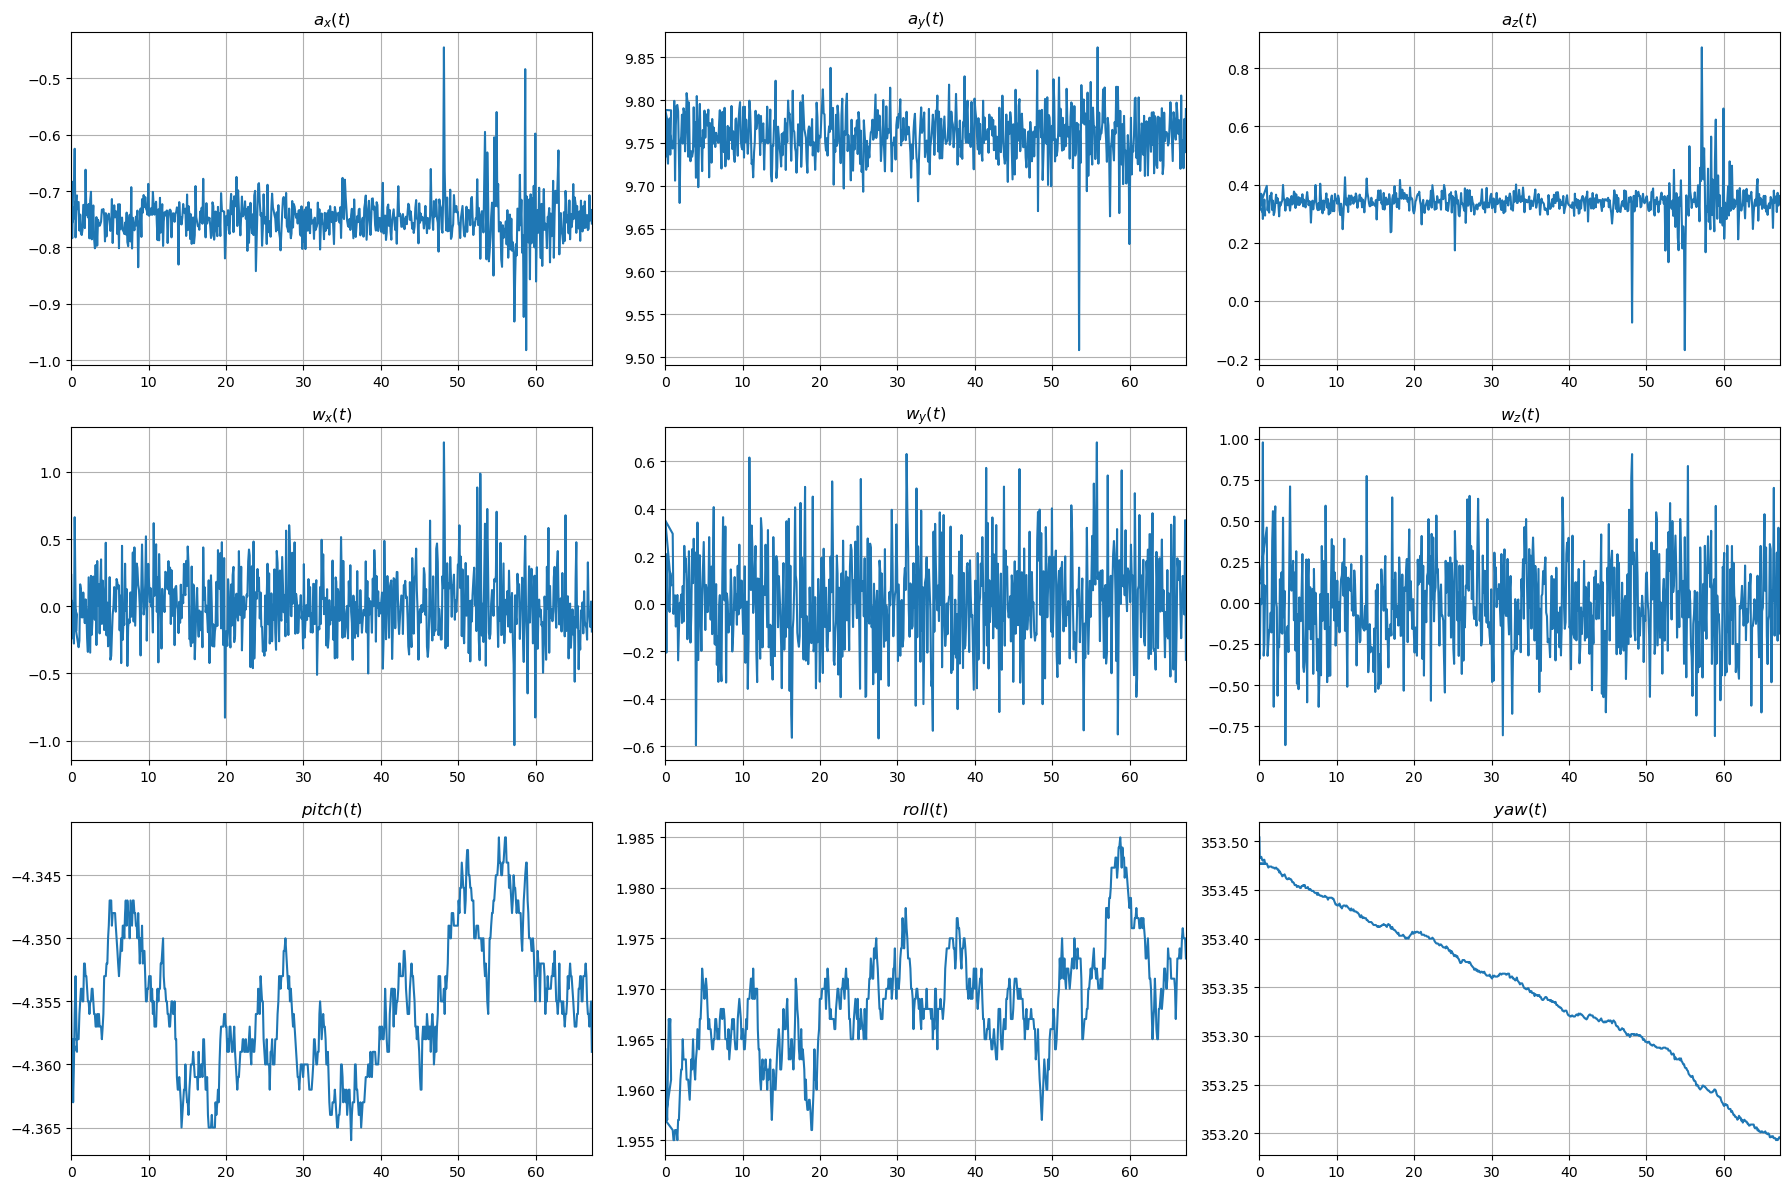

In [8]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

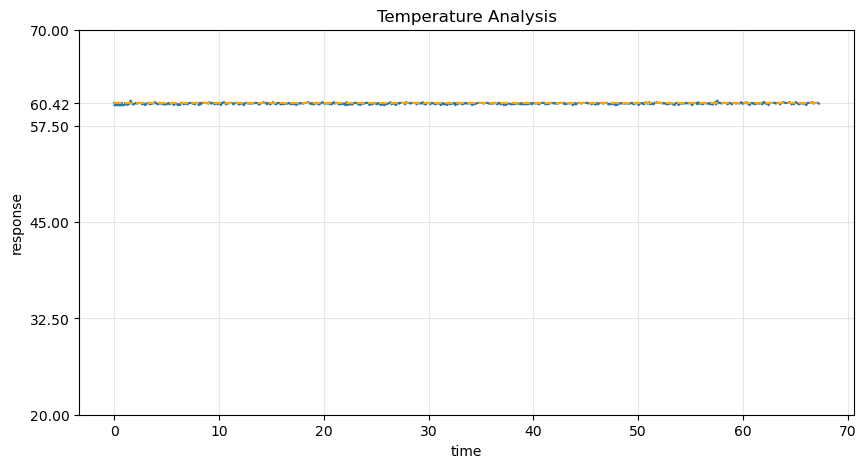

In [9]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

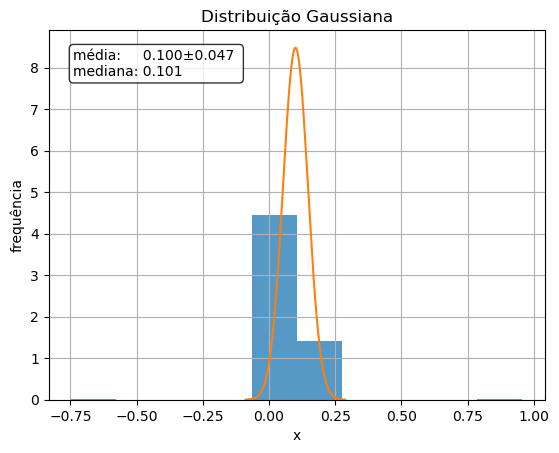

In [10]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [11]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,wx,tmp,wz,yaw,roll,az,wy,pitch,ax,ay
0,0.0,0.04551,60.2,0.12473,353.477,1.957,0.321011,0.35062,-4.358,-0.761653,9.788488
1,0.1,0.01124,60.5,-0.34067,353.484,1.958,0.319922,0.12805,-4.358,-0.778932,9.733845
2,0.2,-0.23899,60.5,0.02385,353.483,1.958,0.359247,-0.20591,-4.359,-0.783649,9.778113
3,0.3,-0.05959,60.2,-0.00802,353.484,1.957,0.368465,0.21019,-4.363,-0.683259,9.739553
4,0.4,-0.27809,60.5,0.21453,353.481,1.963,0.335211,-0.02057,-4.360,-0.700028,9.725775
...,...,...,...,...,...,...,...,...,...,...,...
669,66.9,-0.03999,60.5,0.30606,353.194,1.976,0.305663,0.11702,-4.356,-0.767027,9.752674
670,67.0,-0.08075,60.5,-0.22989,353.193,1.975,0.371741,0.09941,-4.357,-0.707471,9.720430
671,67.1,-0.15441,60.5,0.45741,353.194,1.975,0.327993,-0.04488,-4.356,-0.752111,9.777936
672,67.2,0.03487,60.5,-0.18754,353.196,1.975,0.361601,0.35198,-4.355,-0.733381,9.739112


# FILTRANDO POR VARIAVEL

In [12]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

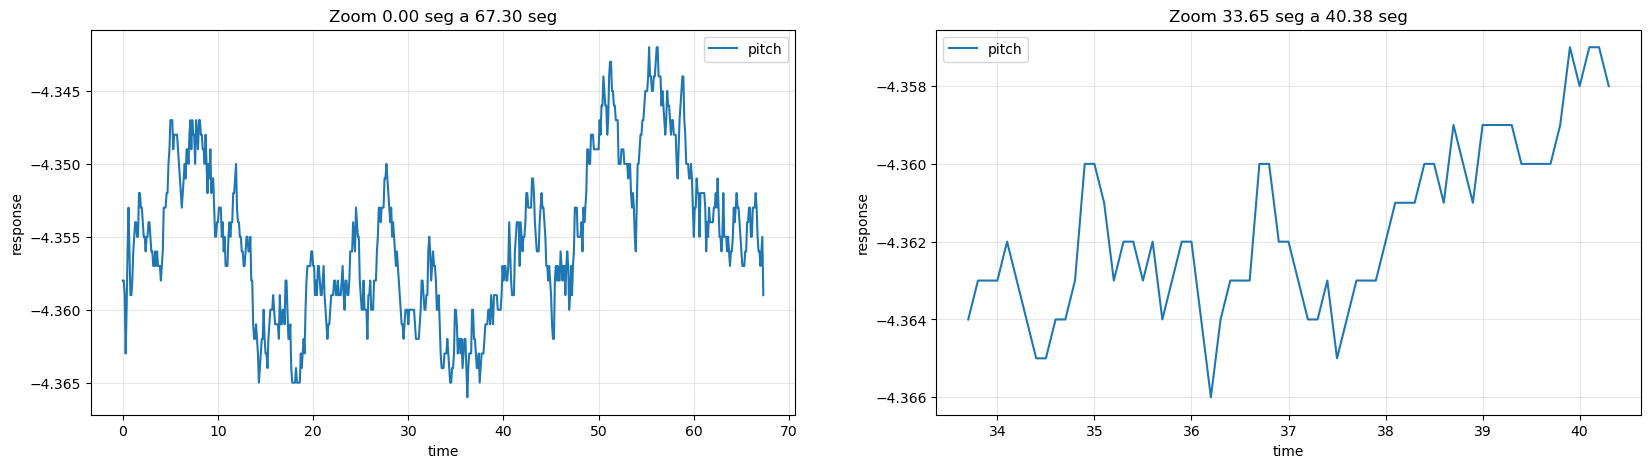

In [13]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [14]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col != 'time'})
df

,time,target_wx,target_tmp,target_wz,target_yaw,target_roll,target_az,target_wy,target_pitch,target_ax,target_ay
0,0.0,0.04551,60.2,0.12473,353.477,1.957,0.321011,0.35062,-4.358,-0.761653,9.788488
1,0.1,0.01124,60.5,-0.34067,353.484,1.958,0.319922,0.12805,-4.358,-0.778932,9.733845
2,0.2,-0.23899,60.5,0.02385,353.483,1.958,0.359247,-0.20591,-4.359,-0.783649,9.778113
3,0.3,-0.05959,60.2,-0.00802,353.484,1.957,0.368465,0.21019,-4.363,-0.683259,9.739553
4,0.4,-0.27809,60.5,0.21453,353.481,1.963,0.335211,-0.02057,-4.360,-0.700028,9.725775
...,...,...,...,...,...,...,...,...,...,...,...
669,66.9,-0.03999,60.5,0.30606,353.194,1.976,0.305663,0.11702,-4.356,-0.767027,9.752674
670,67.0,-0.08075,60.5,-0.22989,353.193,1.975,0.371741,0.09941,-4.357,-0.707471,9.720430
671,67.1,-0.15441,60.5,0.45741,353.194,1.975,0.327993,-0.04488,-4.356,-0.752111,9.777936
672,67.2,0.03487,60.5,-0.18754,353.196,1.975,0.361601,0.35198,-4.355,-0.733381,9.739112


In [15]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)